In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

<div class="alert alert-block alert-info">
<b>K-Nearest Neighbour<b>
</div>

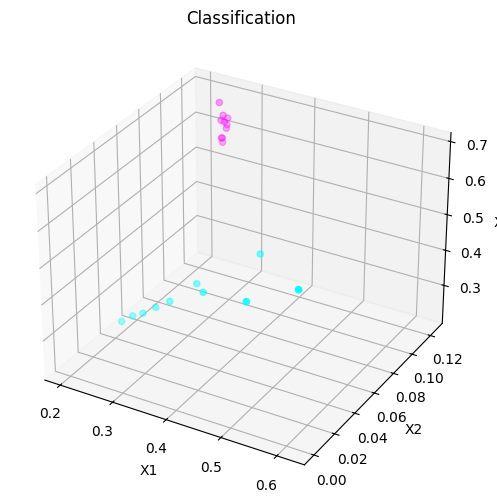

In [49]:

# Load the CSV file
classification = pd.read_csv("train.csv", names=["x_1", "x_2", "x_3", "x_4", "c"])
scaler = StandardScaler()
X_normalized = scaler.fit_transform(classification.iloc[:, :-1])
classification_normalized = pd.DataFrame(X_normalized, columns=["x_1", "x_2", "x_3", "x_4"])
classification_normalized["c"] = classification["c"]  # Reattach class labels
# Create a 3D figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # 3D plot

# Create scatter plot with color mapping
scatter = ax.scatter(
    classification.iloc[:, 0], 
    classification.iloc[:, 1], 
    classification.iloc[:, 2], 
    c=classification.iloc[:, 4],  # Color based on class
    cmap="cool"
)

# Labels and title
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
ax.set_title("Classification")

# Show plot
plt.show()

In [50]:
features = classification_normalized.iloc[:, :-1]  # All columns except the last one (features)
labels = classification_normalized.iloc[:, -1]   # Last column (class labels)
# Split into training and test sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=42)

# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors

# Train the classifier
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Compute accuracy
accuracy = knn.score(X_test, y_test)

# Return predictions and accuracy
y_pred, accuracy

(array([0., 1.]), 1.0)